In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vegetable-image-dataset' dataset.
Path to dataset files: /kaggle/input/vegetable-image-dataset


In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF")
!nvidia-smi

Num GPUs Available:  1
Default GPU Device: /device:GPU:0
Mon Jun  8 04:25:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P0             26W /   70W |     105MiB /  15360MiB |      4%      Default |
|                                         |                        |               

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras import layers, models

# Data directory (handling the kagglehub path)
# Usually the structure is path/Vegetable Images/train
base_dir = os.path.join(path, 'Vegetable Images')
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

# Image generators
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(299, 299), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(validation_dir, target_size=(299, 299), batch_size=32, class_mode='categorical')

# Build InceptionResNetV2 model
base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# Fixed the typo: 'categorical_loss' -> 'categorical_crossentropy'
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training
print("Starting training...")
history = model.fit(train_generator, epochs=20, validation_data=val_generator)

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Starting training...
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 594s 1s/step - accuracy: 0.9225 - loss: 0.2675 - val_accuracy: 0.9807 - val_loss: 0.0562
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 445s 948ms/step - accuracy: 0.9731 - loss: 0.0877 - val_accuracy: 0.9897 - val_loss: 0.0330
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 446s 951ms/step - accuracy: 0.9809 - loss: 0.0608 - val_accuracy: 0.9927 - val_loss: 0.0234
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 447s 952ms/step - accuracy: 0.9823 - loss: 0.0555 - val_accuracy: 0.9940 - val_loss: 0.0198
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 451s 961ms/step - accuracy: 0.9860 - loss: 0.0456 - val_accuracy: 0.9943 - val_loss: 0.0157
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 442s 942ms/step - accuracy: 0.9847 - loss: 0.0452 - val_accuracy: 0.9930 - val_loss: 0.0202
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 446s 949m

In [ ]:
# Summarize training results
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")
model.summary()

94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 314ms/step - accuracy: 0.9987 - loss: 0.0106
Validation Loss: 0.0106
Validation Accuracy: 0.9987


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_resnet_v2             │ (None, 8, 8, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,528,719 (211.83 MB)

 Trainable params: 397,327 (1.52 MB)

 Non-trainable params: 54,336,736 (207.28 MB)

 Optimizer params: 794,656 (3.03 MB)

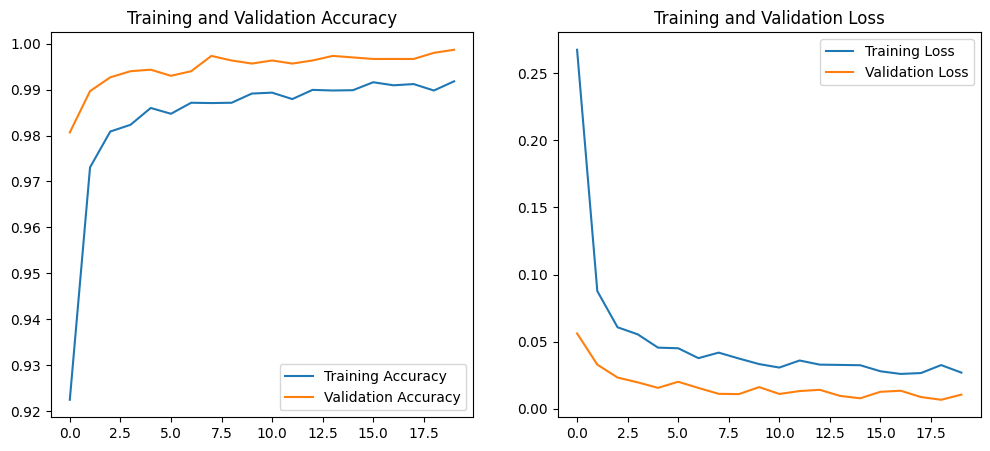

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()